In [1]:
from utils import *

## Schematic figure

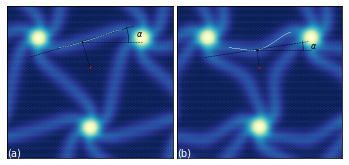

In [2]:
from matplotlib.patches import Arc
colormap='YlGnBu_r'
import matplotlib.gridspec as gridspec

m1 = 'Mo'
m2 = 'W'
x1 = 'S'
ii = 30

SIZE_PT  = 0.7
spacing_factor = 0.5

gs1 = gridspec.GridSpec(1, 2)
gs1.update(wspace=0.025, hspace=0.05)

for h,stacking in enumerate(['P','AP']):
        
    data = np.load(f'grid_data/{m1}{x1}2_{m2}{x1}2_{stacking}_{ii}.npz')
    # Access arrays and variables
    x_sc = data['x_sc']
    y_sc = data['y_sc']
    d_local_sc = data['d_local_sc']

    # initialize plot object
    ax = plt.subplot(gs1[h])
    im = ax.scatter(x_sc, y_sc, c=d_local_sc, s=SIZE_PT,cmap=colormap) # scatter data

    args_max_d = np.where(d_local_sc==max(d_local_sc))[0]
    xs_max_d = x_sc[args_max_d]
    ys_max_d = y_sc[args_max_d]

    #Random index for analysis
    i = 10 
    points = np.column_stack((xs_max_d,ys_max_d))
    distances = cdist(points,points)[i]
    nn1_dist = np.unique(np.round(distances,10))[1] ##Get first nearest neighbours of node
    nn1s = np.where(np.round(distances,10) == nn1_dist)[0]
    nn1_arg_1 = nn1s[np.where((xs_max_d[nn1s]<xs_max_d[i]) & (ys_max_d[nn1s]>ys_max_d[i]))[0][0]]
    nn1_arg_2 = nn1s[np.where((xs_max_d[nn1s]>xs_max_d[i]) & (ys_max_d[nn1s]>ys_max_d[i]))[0][0]]
    x_sol1,x_sol2,x_sol3 = xs_max_d[[i,nn1_arg_1,nn1_arg_2]]
    y_sol1,y_sol2,y_sol3 = ys_max_d[[i,nn1_arg_1,nn1_arg_2]]
    x_cent,y_cent = (x_sol1+x_sol2+x_sol3)/3,(y_sol1+y_sol2+y_sol3)/3
    plt.scatter([x_cent],[y_cent],c='r',s=1)
    #print(f'nn distance : {x_sol3-x_sol2}')

    spacing = int(nn1_dist/spacing_factor)
    x_min,x_max = x_sol2+0.2*nn1_dist,x_sol3-0.2*nn1_dist
    y_min,y_max = y_cent+0.1*nn1_dist,y_cent+0.5*nn1_dist
    x_23,y_23 = get_max_ds(x_sc,y_sc,d_local_sc,x_min,x_max,
                      y_min,y_max,True,spacing=spacing)
    plt.scatter(x_23,y_23,s=0.001,c='w')
    x_closest_23,y_closest_23 = get_closest_point(x_cent,y_cent,x_23,y_23)
    plt.scatter(x_closest_23,y_closest_23,c='k',s=1)
    xtangent_23,ytangent_23,m_23,c_23 = get_tangent(x_cent,x_closest_23,y_cent,y_closest_23,0.5*nn1_dist)
    plt.plot(xtangent_23,ytangent_23,linestyle='--',lw=0.5,c='k')
    plt.plot([x_cent,x_closest_23],[y_cent,y_closest_23],linestyle='--',lw=0.5,c='k')
    plt.plot([x_closest_23,x_sol3],[y_closest_23,y_closest_23],linestyle='--',lw=0.5,c='k')
    twirl_angle = np.rad2deg(np.arctan(m_23))
    #print(f'ii={ii} Twirl angle = {twirl_angles[k]}° spacing ={spacing}')

    arc = Arc(xy=(x_closest_23,y_closest_23),width=0.9*nn1_dist,
              height=0.9*nn1_dist,theta1=-2,theta2=twirl_angle+2,lw=0.5)
    ax.add_patch(arc)
    ax.text(x_closest_23+0.52*nn1_dist,0.5*(m_23*(x_closest_23+0.5*nn1_dist)+c_23+y_closest_23),
            r'$\alpha$',fontsize=8,va='center')
    # ax.set_xlim(-X_NEG, X_POS) # set x limits
    # ax.set_ylim(-Y_NEG, Y_POS) # set y limits
    
    x_lim_low = x_sol2-0.3*nn1_dist
    x_lim_high = x_sol3+0.3*nn1_dist
    y_lim_low = y_sol1-0.3*nn1_dist
    y_lim_high = y_sol2+0.3*nn1_dist

    ax.text(x_lim_low,y_lim_low,f"({chr(ord('a')+h)})",fontsize=10,va='bottom',ha='left',color='white')
        
    ax.set_xlim(x_lim_low,x_lim_high)
    ax.set_ylim(y_lim_low,y_lim_high)
    # remove ticks for x and y axis
    ax.get_xaxis().set_ticks([]) # don't show x-axis ticks
    ax.get_yaxis().set_ticks([]) # don't show y-axis ticks
    ax.set_aspect('equal')

plt.savefig('twirl_schematic.png',dpi=300,facecolor='white',transparent=False,
            bbox_inches='tight',pad_inches=0.02)
plt.show()            

# Plot twirl angle with error analysis

In [5]:
from matplotlib.patches import Arc

m1 = 'Mo'
m2 = 'W'
#spacing_factors = [0.08,0.1,0.13,0.17,0.2]
#spacing_factors = np.linspace(0.07,0.1,3)
spacing_factors = np.linspace(0.07,0.2,10)
#spacing_factors = [0.08,0.1,0.12,0.15]

twirl_dict = {}
for x1 in ['S','Se']:
    
    if x1=='Se':
        iis= [15,16,18,19,20,22,25,27,30,40]
    else:
        iis= [15,16,18,19,20,22,25,27,30]
    
    
    for stacking in ['P','AP']:
        print(f'Starting calculations for {stacking}-{m1}{x1}2/{m2}{x1}2...')
        twirl_angles = np.zeros((len(iis),len(spacing_factors)))
        for k,ii in enumerate(iis):
            
            data = np.load(f'grid_data/{m1}{x1}2_{m2}{x1}2_{stacking}_{ii}.npz')
            # Access arrays and variables
            x_sc = data['x_sc']
            y_sc = data['y_sc']
            d_local_sc = data['d_local_sc']

            args_max_d = np.where(d_local_sc==max(d_local_sc))[0]
            xs_max_d = x_sc[args_max_d]
            ys_max_d = y_sc[args_max_d]

            i=50
        
            
            points = np.column_stack((xs_max_d,ys_max_d))
            distances = cdist(points,points)[i]
            nn1_dist = np.unique(np.round(distances,10))[1] ##Get first nearest neighbours of node
            nn1s = np.where(np.round(distances,10) == nn1_dist)[0]
            nn1_arg_1 = nn1s[np.where((xs_max_d[nn1s]<xs_max_d[i]) & (ys_max_d[nn1s]>ys_max_d[i]))[0][0]]
            nn1_arg_2 = nn1s[np.where((xs_max_d[nn1s]>xs_max_d[i]) & (ys_max_d[nn1s]>ys_max_d[i]))[0][0]]
            x_sol1,x_sol2,x_sol3 = xs_max_d[[i,nn1_arg_1,nn1_arg_2]]
            y_sol1,y_sol2,y_sol3 = ys_max_d[[i,nn1_arg_1,nn1_arg_2]]
            x_cent,y_cent = (x_sol1+x_sol2+x_sol3)/3,(y_sol1+y_sol2+y_sol3)/3

            #print(f'nn distance : {x_sol3-x_sol2}')
            for l,spacing_factor in enumerate(spacing_factors):
                
                spacing = int(nn1_dist/spacing_factor)
                x_min,x_max = x_sol2+0.2*nn1_dist,x_sol3-0.2*nn1_dist
                y_min,y_max = y_cent+0.1*nn1_dist,y_cent+0.5*nn1_dist
                x_23,y_23 = get_max_ds(x_sc,y_sc,d_local_sc,x_min,x_max,
                                  y_min,y_max,True,spacing=spacing)
                x_closest_23,y_closest_23 = get_closest_point(x_cent,y_cent,x_23,y_23)
                xtangent_23,ytangent_23,m_23,c_23 = get_tangent(x_cent,x_closest_23,y_cent,
                                                                y_closest_23,0.3*nn1_dist)


                twirl_angles[k][l] = np.rad2deg(np.arctan(m_23))
                print(f'ii={ii} twirl_angle={twirl_angles[k][l]}° spacing_factor={spacing_factor} spacing={spacing}')
            
        twirl_dict[f'{stacking}-{m1}{m2}{x1}'] = twirl_angles.copy()



Starting calculations for P-MoS2/WS2...
ii=15 twirl_angle=21.263788184722078° spacing_factor=0.07 spacing=1223
ii=15 twirl_angle=21.33299487476622° spacing_factor=0.08444444444444445 spacing=1013
ii=15 twirl_angle=20.66527237293945° spacing_factor=0.0988888888888889 spacing=865
ii=15 twirl_angle=21.536612852803483° spacing_factor=0.11333333333333334 spacing=755
ii=15 twirl_angle=21.061548521722397° spacing_factor=0.1277777777777778 spacing=670
ii=15 twirl_angle=21.64223572883534° spacing_factor=0.14222222222222225 spacing=602
ii=15 twirl_angle=20.541609397398794° spacing_factor=0.15666666666666668 spacing=546
ii=15 twirl_angle=20.50874112837012° spacing_factor=0.17111111111111113 spacing=500
ii=15 twirl_angle=21.240413780343744° spacing_factor=0.18555555555555558 spacing=461
ii=15 twirl_angle=20.427042395900937° spacing_factor=0.2 spacing=428
ii=16 twirl_angle=21.960837269623806° spacing_factor=0.07 spacing=1302
ii=16 twirl_angle=21.96518145569624° spacing_factor=0.08444444444444445 sp

ii=16 twirl_angle=19.54353029413476° spacing_factor=0.07 spacing=1302
ii=16 twirl_angle=20.060843099283034° spacing_factor=0.08444444444444445 spacing=1079
ii=16 twirl_angle=19.058620524450042° spacing_factor=0.0988888888888889 spacing=921
ii=16 twirl_angle=18.937022344120866° spacing_factor=0.11333333333333334 spacing=804
ii=16 twirl_angle=20.701179166314212° spacing_factor=0.1277777777777778 spacing=713
ii=16 twirl_angle=20.839084876680896° spacing_factor=0.14222222222222225 spacing=640
ii=16 twirl_angle=19.13038164847586° spacing_factor=0.15666666666666668 spacing=581
ii=16 twirl_angle=20.831841556219377° spacing_factor=0.17111111111111113 spacing=532
ii=16 twirl_angle=18.973367606996458° spacing_factor=0.18555555555555558 spacing=491
ii=16 twirl_angle=18.46911445961251° spacing_factor=0.2 spacing=455
ii=18 twirl_angle=19.515457048125743° spacing_factor=0.07 spacing=1459
ii=18 twirl_angle=19.751402855149184° spacing_factor=0.08444444444444445 spacing=1210
ii=18 twirl_angle=19.276098

ii=18 twirl_angle=17.830879450865368° spacing_factor=0.07 spacing=1521
ii=18 twirl_angle=18.01976928178243° spacing_factor=0.08444444444444445 spacing=1260
ii=18 twirl_angle=17.67262739204308° spacing_factor=0.0988888888888889 spacing=1076
ii=18 twirl_angle=18.465072784143857° spacing_factor=0.11333333333333334 spacing=939
ii=18 twirl_angle=18.519831397143374° spacing_factor=0.1277777777777778 spacing=833
ii=18 twirl_angle=18.34040141780057° spacing_factor=0.14222222222222225 spacing=748
ii=18 twirl_angle=17.475938733620016° spacing_factor=0.15666666666666668 spacing=679
ii=18 twirl_angle=17.661036216989924° spacing_factor=0.17111111111111113 spacing=622
ii=18 twirl_angle=18.360827545371745° spacing_factor=0.18555555555555558 spacing=573
ii=18 twirl_angle=18.621146151014717° spacing_factor=0.2 spacing=532
ii=19 twirl_angle=18.383700375489436° spacing_factor=0.07 spacing=1603
ii=19 twirl_angle=18.49675654384021° spacing_factor=0.08444444444444445 spacing=1329
ii=19 twirl_angle=18.483269

ii=18 twirl_angle=12.488085768952278° spacing_factor=0.07 spacing=1521
ii=18 twirl_angle=11.292152558531319° spacing_factor=0.08444444444444445 spacing=1260
ii=18 twirl_angle=11.466136502271558° spacing_factor=0.0988888888888889 spacing=1076
ii=18 twirl_angle=11.954482802496711° spacing_factor=0.11333333333333334 spacing=939
ii=18 twirl_angle=12.238535393821323° spacing_factor=0.1277777777777778 spacing=833
ii=18 twirl_angle=12.599282187160517° spacing_factor=0.14222222222222225 spacing=748
ii=18 twirl_angle=12.218264519649294° spacing_factor=0.15666666666666668 spacing=679
ii=18 twirl_angle=12.374183799258894° spacing_factor=0.17111111111111113 spacing=622
ii=18 twirl_angle=12.680383491823633° spacing_factor=0.18555555555555558 spacing=573
ii=18 twirl_angle=12.849544091499357° spacing_factor=0.2 spacing=532
ii=19 twirl_angle=11.331578026265387° spacing_factor=0.07 spacing=1603
ii=19 twirl_angle=11.257702972069106° spacing_factor=0.08444444444444445 spacing=1329
ii=19 twirl_angle=10.59

In [6]:
import pickle

with open('twirl_angles.pkl', 'wb') as f:
    pickle.dump(twirl_dict, f)

In [7]:
import pickle
with open('twirl_angles.pkl', 'rb') as f:
    twirl_dict = pickle.load(f)

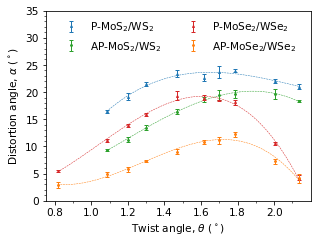

In [11]:
from matplotlib.ticker import MultipleLocator

m1 = 'Mo'
m2 = 'W'
npoly=2
iis= [15,16,18,19,20,22,25,27,30]
fontsize = 8.5+2
plt.rcParams['font.size'] = fontsize
plt.figure(figsize=(4.75,3.5))

prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
plt_colors = {'P-MoS2/WS2':colors[0],'AP-MoS2/WS2':colors[2],'P-MoSe2/WSe2':colors[3],'AP-MoSe2/WSe2':colors[1]}


for x1 in ['S','Se']:
    if x1=='Se':
        iis= [15,16,18,19,20,22,25,27,30,40]
    else:
        iis= [15,16,18,19,20,22,25,27,30]
    for stacking in ['P','AP']:
        if stacking == 'P':
            marker = '^'
        else:
            marker = 'H'
            
         
        label = rf'{stacking}-{m1}{x1}$_2$/{m2}{x1}$_2$'
        angles = [twist_angles[ii] for ii in iis]
        dict_data = twirl_dict[f'{stacking}-{m1}{m2}{x1}']
        means = np.mean(dict_data,axis=1)
        stds = np.std(dict_data,axis=1)
        
        color = plt_colors[f'{stacking}-{m1}{x1}2/{m2}{x1}2']
        errorplot = plt.errorbar(angles,means,yerr=stds,fmt=marker,label =label,markersize=2,
                    elinewidth=1,capsize=2,capthick=1,barsabove=True,color=color)

        if m1!=m2:# and x1=='Se':
            npoly=3
        else:
            npoly=2 
        
        poly = np.polyfit(angles,means,npoly)
        poly_angles = np.linspace(min(angles),max(angles),150)
        poly_means = np.polyval(poly,poly_angles)
        
        plt.plot(poly_angles,poly_means,color=errorplot[0].get_color(),linestyle='--',lw=0.5)
        
#         plt.scatter(twist_angles,dict_data,
#                 label = label,marker=marker,s=50)
plt.gca().xaxis.set_minor_locator(MultipleLocator(0.1))
plt.gca().yaxis.set_minor_locator(MultipleLocator(1))
plt.xlabel(r'Twist angle, $\theta\ (^\circ)$')
plt.ylabel(r'Distortion angle, $\alpha\ (^\circ)$')
plt.ylim(0,35)
#plt.xlim(1,2.5)
plt.legend(frameon=False,loc='upper center',fontsize=fontsize,ncol=2)
plt.savefig('twirl_angles.png',dpi=300,facecolor='white',transparent=False,
            bbox_inches='tight',pad_inches=0.02)
plt.show()